<a href="https://colab.research.google.com/github/springboardmentor2468a-lab/Projects_2/blob/Humera/Week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# TASK 1: Import necessary libraries

import io
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

plt.rcParams['figure.figsize'] = (10, 5)
sns.set(style="whitegrid")

In [2]:
# TASK 2: Upload and load hour.csv and day.csv


print("Upload hour dataset (e.g., hour.csv):")
uploaded = files.upload()
hour_fname = next(iter(uploaded))

if hour_fname.lower().endswith('.csv'):
    hour_df = pd.read_csv(io.BytesIO(uploaded[hour_fname]))
else:
    hour_df = pd.read_excel(io.BytesIO(uploaded[hour_fname]))
print("Loaded", hour_fname, "shape:", hour_df.shape)

print("\nUpload day dataset (e.g., day.csv):")
uploaded = files.upload()
day_fname = next(iter(uploaded))
if day_fname.lower().endswith('.csv'):
    day_df = pd.read_csv(io.BytesIO(uploaded[day_fname]))
else:
    day_df = pd.read_excel(io.BytesIO(uploaded[day_fname]))
print("Loaded", day_fname, "shape:", day_df.shape)

Upload hour dataset (e.g., hour.csv):


Saving day.csv to day.csv
Loaded day.csv shape: (731, 16)

Upload day dataset (e.g., day.csv):


Saving hour.csv to hour.csv
Loaded hour.csv shape: (17379, 17)


In [10]:
# Quick peek

display(Markdown("### Hour dataset head"))
display(hour_df.head())
display(Markdown("### Day dataset head"))
display(day_df.head())

### Hour dataset head

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


### Day dataset head

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [11]:
# TASK 3: Basic Cleaning and Feature Removal

print("\n===== BASIC CLEANING =====")

def basic_clean(df, name):
    print(f"\n{name} Shape: {df.shape}")
    print(f"Null Values:\n{df.isnull().sum()}")
    print("Duplicate rows:", df.duplicated().sum())

    # Normalize column names
    df.columns = [c.strip() for c in df.columns]

    # Preview dteday parsing
    if 'dteday' in df.columns:
        parsed = pd.to_datetime(df['dteday'], errors='coerce')
        print("Parsed dteday count:", parsed.notna().sum())

    return df

hour_df = basic_clean(hour_df, "hour_df")
day_df  = basic_clean(day_df,  "day_df")


# ✅ Remove unnecessary columns (Feature Removal)

columns_to_drop_day = ['instant', 'dteday', 'yr', 'casual', 'registered']
columns_to_drop_hour = ['instant', 'dteday', 'yr', 'casual', 'registered']

day_df.drop(columns=columns_to_drop_day, inplace=True, errors='ignore')
hour_df.drop(columns=columns_to_drop_hour, inplace=True, errors='ignore')

print("\nColumns removed successfully.")

# ✅ Convert numeric-like strings to numeric

def convert_numeric(df):
    for col in df.columns:
        if df[col].dtype == object:
            try:
                df[col] = pd.to_numeric(df[col])
            except:
                pass
    return df

hour_df = convert_numeric(hour_df)
day_df  = convert_numeric(day_df)

# ✅ Show updated info

print("\n===== hour_df.info() =====")
hour_df.info()

print("\n===== day_df.info() =====")
day_df.info()

display(Markdown("### Cleaned Hour Dataset"))
display(hour_df.head())
display(Markdown("### Cleaned Day Dataset"))
display(day_df.head())



===== BASIC CLEANING =====

hour_df Shape: (717, 11)
Null Values:
season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64
Duplicate rows: 0

day_df Shape: (16535, 12)
Null Values:
season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64
Duplicate rows: 2

Columns removed successfully.

===== hour_df.info() =====
<class 'pandas.core.frame.DataFrame'>
Index: 717 entries, 0 to 730
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      717 non-null    int64  
 1   mnth        717 non-null    int64  
 2   holiday     717 non-null    int64  
 3   weekday     717 non-null    int64  
 4   workingday  717 non-null    int64  
 5   weathersit  

### Cleaned Hour Dataset

,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


### Cleaned Day Dataset

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [12]:
print(hour_df.isnull().sum())

season        0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


In [13]:
print(day_df.isnull().sum())


season        0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


In [14]:
print("Hour dataset shape:", hour_df.shape)
print("Day dataset shape:", day_df.shape)

Hour dataset shape: (717, 11)
Day dataset shape: (16535, 12)



===== OUTLIER REMOVAL USING IQR =====


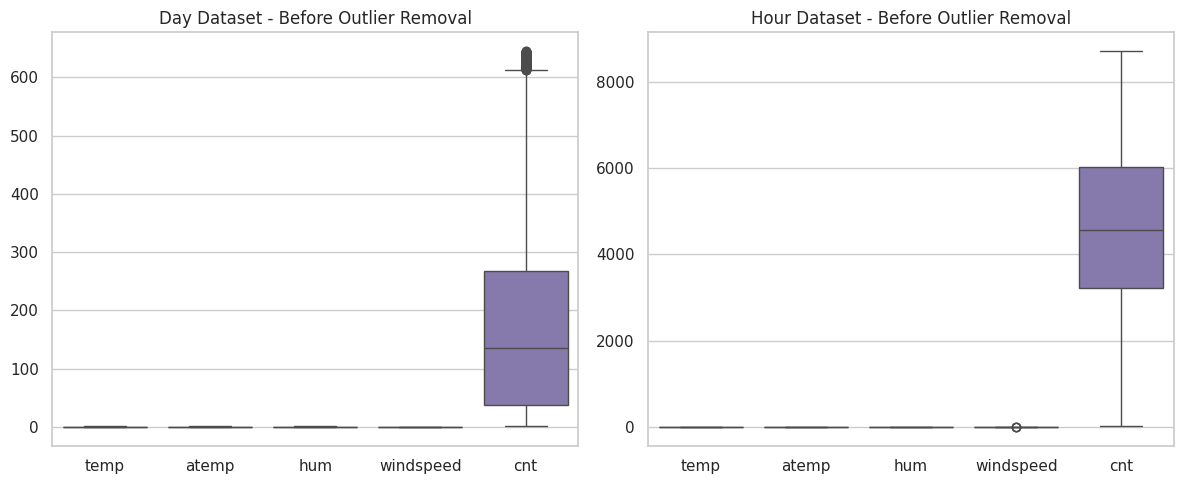

In [15]:
# ✅ TASK 4: Outlier Detection & Removal (IQR Method)

print("\n===== OUTLIER REMOVAL USING IQR =====")

# Select numeric columns
numeric_cols = ['temp','atemp','hum','windspeed','cnt']
numeric_day  = [c for c in numeric_cols if c in day_df.columns]
numeric_hour = [c for c in numeric_cols if c in hour_df.columns]

def remove_outliers(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean

# ✅ Boxplot before removal
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=day_df[numeric_day])
plt.title("Day Dataset - Before Outlier Removal")

plt.subplot(1,2,2)
sns.boxplot(data=hour_df[numeric_hour])
plt.title("Hour Dataset - Before Outlier Removal")

plt.tight_layout()
plt.show()



Day dataset rows before: 16535 | after: 16410
Hour dataset rows before: 717 | after: 714


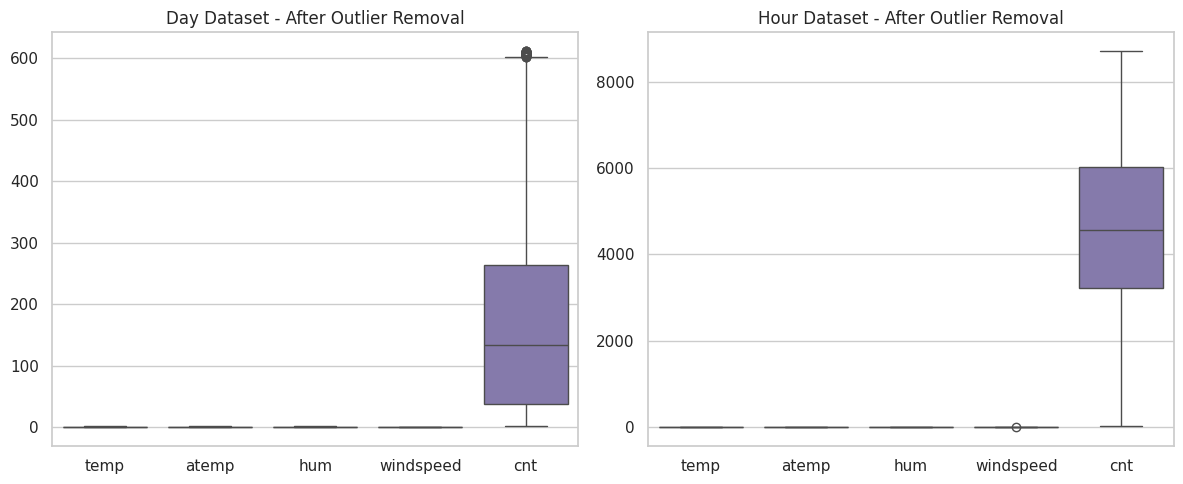


✅ Outlier removal completed.


In [16]:
# ✅ Apply outlier removal
day_before = day_df.shape[0]
hour_before = hour_df.shape[0]

day_df = remove_outliers(day_df, numeric_day)
hour_df = remove_outliers(hour_df, numeric_hour)

day_after = day_df.shape[0]
hour_after = hour_df.shape[0]

print("\nDay dataset rows before:", day_before, "| after:", day_after)
print("Hour dataset rows before:", hour_before, "| after:", hour_after)

# ✅ Boxplot after removal
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=day_df[numeric_day])
plt.title("Day Dataset - After Outlier Removal")

plt.subplot(1,2,2)
sns.boxplot(data=hour_df[numeric_hour])
plt.title("Hour Dataset - After Outlier Removal")

plt.tight_layout()
plt.show()

print("\n✅ Outlier removal completed.")